In [1]:
from core.data_reader import average_precipitation_germany, daily_average_germany, monthly_average_germany, monthly_total_germany, print_metadata, total_precipitation, yearly_potato_yield
import os
from matplotlib import pyplot as plt
import tqdm
import numpy as np

['pr_hyras_1_2025_v6-1_de.nc', 'pr_hyras_1_2024_v6-1_de.nc', 'pr_hyras_1_2023_v6-1_de.nc', 'pr_hyras_1_2022_v6-1_de.nc', 'pr_hyras_1_2021_v6-1_de.nc', 'pr_hyras_1_2020_v6-1_de.nc', 'pr_hyras_1_2019_v6-1_de.nc', 'pr_hyras_1_2018_v6-1_de.nc', 'pr_hyras_1_2017_v6-1_de.nc', 'pr_hyras_1_2016_v6-1_de.nc', 'pr_hyras_1_2015_v6-1_de.nc', 'pr_hyras_1_2014_v6-1_de.nc', 'pr_hyras_1_2013_v6-1_de.nc', 'pr_hyras_1_2012_v6-1_de.nc', 'pr_hyras_1_2011_v6-1_de.nc', 'pr_hyras_1_2010_v6-1_de.nc', 'pr_hyras_1_2009_v6-1_de.nc', 'pr_hyras_1_2008_v6-1_de.nc', 'pr_hyras_1_2007_v6-1_de.nc', 'pr_hyras_1_2006_v6-1_de.nc', 'pr_hyras_1_2005_v6-1_de.nc', 'pr_hyras_1_2004_v6-1_de.nc', 'pr_hyras_1_2003_v6-1_de.nc', 'pr_hyras_1_2002_v6-1_de.nc', 'pr_hyras_1_2001_v6-1_de.nc', 'pr_hyras_1_2000_v6-1_de.nc', 'pr_hyras_1_1999_v6-1_de.nc', 'pr_hyras_1_1998_v6-1_de.nc', 'pr_hyras_1_1997_v6-1_de.nc', 'pr_hyras_1_1996_v6-1_de.nc', 'pr_hyras_1_1995_v6-1_de.nc', 'pr_hyras_1_1994_v6-1_de.nc', 'pr_hyras_1_1993_v6-1_de.nc', 'pr_hyras

Processing files: 100%|██████████| 76/76 [03:45<00:00,  2.97s/it]


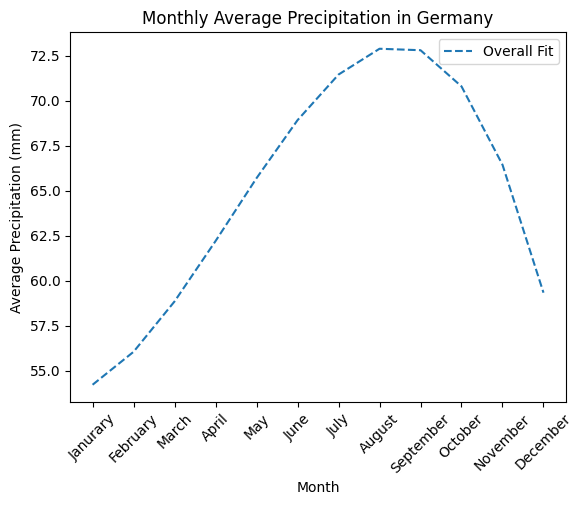

In [ ]:
files = []
counter = 0


for file in os.listdir('.data'):
    if file.endswith('.nc'):
        if counter > 100:
            break
        files.append(file)

        counter += 1

files_sorted = sorted(files, key=lambda x: x.split('_')[3])
print(files_sorted)

months = ["Janurary", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

nc_files = [f for f in files_sorted if f.endswith('.nc')]

results = []
for file in tqdm.tqdm(nc_files, desc="Processing files"):
    filename = os.path.join('.data', file)
    avg_precip = monthly_total_germany(filename)
    results.append((file.split('_')[3], avg_precip[1]))

#for label, data in results:
    #plt.plot(months, data, label=label)

overall_monthly_average_totals = [(month_name, 0) for month_name in months]

for i, r in enumerate(results):
    for j, month in enumerate(r[1]):
        overall_monthly_average_totals[j] = (overall_monthly_average_totals[j][0], overall_monthly_average_totals[j][1] + month)
overall_precipitation = [x[1] / len(results) for x in overall_monthly_average_totals]

fit_curve = np.polyfit(range(len(months)), overall_precipitation, 3)
fit_func = np.poly1d(fit_curve)
plt.plot(months, fit_func(range(len(months))), label='Overall Fit', linestyle='--')
plt.xlabel('Month')
plt.ylabel('Average Precipitation (mm)')
plt.title('Monthly Average Precipitation in Germany')
plt.legend()
plt.xticks(rotation=45)
plt.show()

Processing files: 100%|██████████| 76/76 [03:37<00:00,  2.87s/it]


[('2025', 231220352.0), ('2024', 323642240.0), ('2023', 344066624.0), ('2022', 240354432.0), ('2021', 287773440.0), ('2020', 253081408.0), ('2019', 264575488.0), ('2018', 211409760.0), ('2017', 313758144.0), ('2016', 267271104.0), ('2015', 256020992.0), ('2014', 265243440.0), ('2013', 285640704.0), ('2012', 280809952.0), ('2011', 263873248.0), ('2010', 311980992.0), ('2009', 287130560.0), ('2008', 276328960.0), ('2007', 344143296.0), ('2006', 266489008.0), ('2005', 278526848.0), ('2004', 288492800.0), ('2003', 215979744.0), ('2002', 361450368.0), ('2001', 329968096.0), ('2000', 291565888.0), ('1999', 297591872.0), ('1998', 327972512.0), ('1997', 254098496.0), ('1996', 242707488.0), ('1995', 311996576.0), ('1994', 317173248.0), ('1993', 315117248.0), ('1992', 283174976.0), ('1991', 229648928.0), ('1990', 282413952.0), ('1989', 245146816.0), ('1988', 310615744.0), ('1987', 315366080.0), ('1986', 308470144.0), ('1985', 261826416.0), ('1984', 294419200.0), ('1983', 280155072.0), ('1982', 2

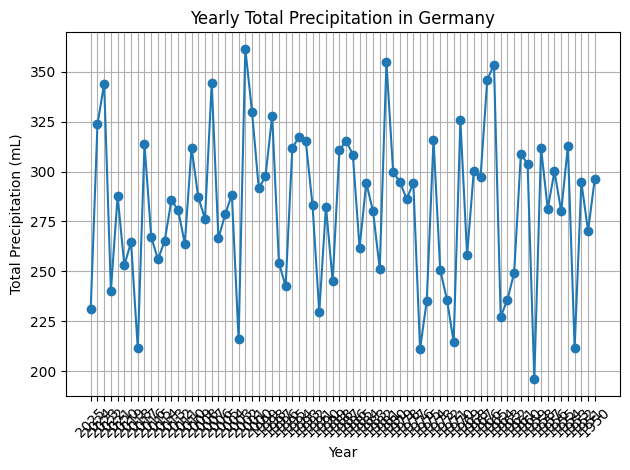

In [ ]:
yearly_precipitation = []
for file in tqdm.tqdm(files_sorted, desc="Processing files"):
    filename = os.path.join('.data', file)
    yearly_precipitation.append((file.split('_')[3], total_precipitation(filename)))

print(yearly_precipitation)

plt.plot([x[0] for x in yearly_precipitation], [x[1]/1_000_000 for x in yearly_precipitation], marker='o')
plt.xlabel('Year')
plt.ylabel('Total Precipitation (mL)')
plt.title('Yearly Total Precipitation in Germany')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid()
plt.show()

In [ ]:
for i in range(1951, 2009):
    potato_yield = yearly_potato_yield('.data/41241-0002_de_flat.csv', i)
    print(f"Year: {i}, Potato Yield: {potato_yield} tons")